# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків — і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе, що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили. Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним. Код, який нічого не пояснює, коштує двох балів з чотирьох.

## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче, `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку, результат може залежати від історії запусків. Перед здачею обов'язково **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [157]:
ПІБ = 'Кривичко Назар'      
ГРУПА = 'ШІ-34'      
ВАРІАНТ = 11     

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [158]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Кривичко Назар, ШІ-34, варіант 11
ваш потік:                   P>10
ваша пара для графіка 3:     радіопотік F10.7 та потік P>10
ваш агрегат для етапу 4:     середнє
ваше додаткове питання:      Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1

Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` — і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [160]:
import pandas as pd

df_naive = pd.read_excel(ФАЙЛ)
print('Розмір:', df_naive.shape)
print('\nНазви стовпців:')
print(list(df_naive.columns))
print('\nТипи стовпців:')
print(df_naive.dtypes)

df_naive.head(10)

Розмір: (7225, 32)

Назви стовпців:
['Unnamed: 0', 'ftp://ftp.swpc.noaa.gov/pub/lists/particle/', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'http://umtof.umd.edu/pm/crn/', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31']

Типи стовпців:
Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
5,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >30 = Particles at >30 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** Тому що ми читали файл разом з текстом заголовків

### Завдання 1.2

Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`. Виведіть його розмір і подивіться на перші 30 рядків.

In [161]:
import pandas as pd

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'
RAW = pd.read_excel(ФАЙЛ, header=None)
print('Розмір:', RAW.shape)
print('\nНазви стовпців:')
print(list(RAW.columns))
print('\nТипи стовпців:')
print(RAW.dtypes)

RAW.head(10)

Розмір: (7226, 32)

Назви стовпців:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

Типи стовпців:
0     float64
1      object
2      object
3      object
4      object
5      object
6      object
7      object
8      object
9      object
10     object
11     object
12     object
13     object
14     object
15    float64
16     object
17     object
18     object
19     object
20    float64
21    float64
22    float64
23    float64
24    float64
25    float64
26     object
27     object
28     object
29     object
30     object
31     object
dtype: object


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3

Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок (`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень. За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [162]:
заповнені = RAW.notna().sum()
print(заповнені.to_string())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602


**Відповідь 1.3:** 3 таблиці ( розрізаються по нулям ) A - 1-14, B - 16-19, C- 24-31

### Завдання 1.4

Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає, і без них ви не знатимете, у чому вимірюєте.*

In [163]:
for назва, кол in [('A', slice(1, 15)), ('B', slice(16, 20)), ('C', slice(24, 32))]:
    print('=' * 70, '\nТАБЛИЦЯ', назва)
    for idx, row in RAW.iloc[:30, кол].iterrows():
        vals = [str(v) for v in row if pd.notna(v)]
        if vals:
            print(f'  {idx:>2}:', ' | '.join(vals)[:150])

ТАБЛИЦЯ A
   0: ftp://ftp.swpc.noaa.gov/pub/lists/particle/
   2: :Data_list: 20170901_Gs_part_5m.txt
   3: :Created: 2017 Sep 02 0011 UTC
   4: # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
   5: # Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
   6: # 
   7: # Label: P > 1 = Particles at >1 Mev
   8: # Label: P > 5 = Particles at >5 Mev
   9: # Label: P >10 = Particles at >10 Mev
  10: # Label: P >30 = Particles at >30 Mev
  11: # Label: P >50 = Particles at >50 Mev
  12: # Label: P>100 = Particles at >100 Mev
  13: # Label: E>0.8 = Electrons at >0.8 Mev
  14: # Label: E>2.0 = Electrons at >2.0 Mev
  15: # Label: E>4.0 = Electrons at >4.0 Mev
  16: # Units: Particles = Protons/cm2-s-sr
  17: # Units: Electrons = Electrons/cm2-s-sr
  18: # Source: GOES-15
  19: # Location: W135
  20: # Missing data: -1.00e+05
  22: 5-minute  GOES-15 Solar Particle and Electron Flux
  23: Modified | Seconds
  24: # UT | C D | ate | Time | Julian | of 

**Відповідь 1.4:**

| Таблиця | Джерело  | Одиниці вимірювання                                        |
|---|----------|------------------------------------------------------------|
| A | GOES-15 W135 | Protons/cm2-s-sr, Electrons/cm2-s-sr, Electrons, Particles |
| B | Quarterly Daily Solar Data         | Radio Flux v10.7, Months, dates                            |
| C | SOHO CELIAS Proton Monitor         | km/sec, protons per cubic centimeter, Year, Month, Day of Month, Day of Year, Hour, Minute, Second                     |

# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1

Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`. Дайте стовпцям осмислені назви й перетворіть значення на числа (`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [164]:
def нарізати(рядки, стовпці, назви):
    т = RAW.iloc[рядки, стовпці].copy()
    т.columns = назви
    т = т.apply(pd.to_numeric, errors='coerce')
    return т.reset_index(drop=True)

A = нарізати(slice(26, 7226), slice(1, 15),
             ['рік', 'місяць', 'день', 'hhmm', 'julian_day', 'сек_доби',
              'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0'])

B = нарізати(slice(27, 52), slice(16, 20),
             ['рік', 'місяць', 'день', 'F10.7'])

C = нарізати(slice(27, 628), slice(24, 32),
             ['лічильник_1', 'лічильник_2', 'рік', 'місяць', 'день', 'година',
              'швидкість', 'густина'])

for n, t in [('A', A), ('B', B), ('C', C)]:
    print(n, t.shape, '| стовпців типу object:', (t.dtypes == 'object').sum())

A (7200, 14) | стовпців типу object: 0
B (25, 4) | стовпців типу object: 0
C (601, 8) | стовпців типу object: 0


### Завдання 2.2

У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях. Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року. Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [165]:
A['ts'] = pd.to_datetime(dict(year=A['рік'], month=A['місяць'], day=A['день'])) \
          + pd.to_timedelta(A['hhmm'] // 100, unit='h') \
          + pd.to_timedelta(A['hhmm'] % 100,  unit='m')

B['ts'] = pd.to_datetime(dict(year=B['рік'], month=B['місяць'], day=B['день']))

C['ts'] = pd.to_datetime(dict(year=C['рік'] + 2000, month=C['місяць'], day=C['день'])) \
          + pd.to_timedelta(C['година'], unit='h')

for назва, т in [('A', A), ('B', B), ('C', C)]:
    print('%s: %s -> %s' % (назва, т['ts'].min(), т['ts'].max()))

A: 2017-08-28 00:00:00 -> 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 -> 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 -> 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [166]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


# Етап 3. Паспорт даних

### Завдання 3.1

Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [167]:
for назва, т in [('A', A), ('B', B), ('C', C)]:
    print('=' * 78)
    print('ТАБЛИЦЯ %s   розмір: %d рядків × %d стовпців' % (назва, т.shape[0], т.shape[1]))
    print('-' * 78)
    print('Типи стовпців:');           print(т.dtypes.to_string())
    print('\nПропуски (NaN) по стовпцях:'); print(т.isna().sum().to_string())
    print('\nПовних дублікатів рядків:', т.duplicated().sum())
    print('\nОписові статистики:');     print(т.describe().T.to_string())
    print()

ТАБЛИЦЯ A   розмір: 7200 рядків × 15 стовпців
------------------------------------------------------------------------------
Типи стовпців:
рік                    int64
місяць                 int64
день                   int64
hhmm                   int64
julian_day             int64
сек_доби               int64
P>1                  float64
P>5                  float64
P>10                 float64
P>30                 float64
P>50                 float64
P>100                float64
E>0.8                float64
E>2.0                float64
ts            datetime64[ns]

Пропуски (NaN) по стовпцях:
рік           0
місяць        0
день          0
hhmm          0
julian_day    0
сек_доби      0
P>1           3
P>5           3
P>10          3
P>30          3
P>50          3
P>100         3
E>0.8         3
E>2.0         3
ts            0

Повних дублікатів рядків: 0

Описові статистики:
             count                 mean                  min                  25%                  50%    

### Завдання 3.2 — дивні значення

Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**. Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [168]:
для_заміни = ['швидкість', 'густина']
до = C[для_заміни].agg(['mean', 'min'])

for стовпець in для_заміни:
    маска = C[стовпець] < 0
    print('%s: від\'ємних значень %d, унікальні значення: %s'
          % (стовпець, маска.sum(), sorted(C.loc[маска, стовпець].unique())))

C[для_заміни] = C[для_заміни].mask(C[для_заміни] < 0)

після = C[для_заміни].agg(['mean', 'min'])
порівняння = pd.concat([до.T.add_suffix('_до'), після.T.add_suffix('_після')], axis=1)
print(порівняння.round(3).to_string())
print('\nNaN після заміни:'); print(C[для_заміни].isna().sum().to_string())

швидкість: від'ємних значень 8, унікальні значення: [np.int64(-1)]
густина: від'ємних значень 8, унікальні значення: [np.float64(-1.0)]
           mean_до  min_до  mean_після  min_після
швидкість  506.547    -1.0     513.395      277.0
густина      2.908    -1.0       2.960        0.1

NaN після заміни:
швидкість    8
густина      8


**Відповідь 3.2:** Тому що ми рахували середнє вораховуючи -1 а це значення означало "нічого" в таблиці і замінивши на NaN ми більше не враховуємо це в середнє і мінімум

### Завдання 3.3 — питання на подумати

У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [169]:
службові = ['рік', 'місяць', 'день', 'hhmm', 'julian_day', 'сек_доби']
print(A[службові].describe().T[['mean', 'std', 'min', 'max']].round(2).to_string())

print('\nhhmm: унікальних значень', A['hhmm'].nunique(),
      '| приклади:', sorted(A['hhmm'].unique())[:5], '...', sorted(A['hhmm'].unique())[-3:])
print('день: унікальні ->', sorted(A['день'].unique()))

                mean       std      min      max
рік          2017.00      0.00   2017.0   2017.0
місяць          8.84      0.37      8.0      9.0
день           13.96      8.78      1.0     31.0
hhmm         1177.50    692.48      0.0   2355.0
julian_day  58005.00      7.21  57993.0  58017.0
сек_доби    43050.00  24943.11      0.0  86100.0

hhmm: унікальних значень 288 | приклади: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)] ... [np.int64(2345), np.int64(2350), np.int64(2355)]
день: унікальні -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]


**Відповідь 3.3:** Шкала не є числовою в потрібному сенсі. Для день середнє 13.96 при діапазоні 1–31 виглядає осмислено, але це ілюзія: дні місяця циклічні, 31-е і 1-е стоять поруч у часі, хоча як числа вони максимально далекі. Усереднювати циклічну величину як звичайну — помилка. Середнє від julian_day (58005.4) — це число без фізичного змісту, бо ці стовпці нічого не вимірюють, вони адресують рядок

# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1

Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа за годину: середнє і максимум.

In [170]:
потоки = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_год = (A.set_index('ts')[потоки]
         .resample('1h')
         .agg(['mean', 'max']))

A_год.columns = ['%s_%s' % (потік, агр) for потік, агр in A_год.columns]
A_год = A_год.reset_index()

print(A_год.shape)
print(A_год.iloc[:4, :5].to_string())

(600, 17)
                   ts  P>1_mean  P>1_max  P>5_mean  P>5_max
0 2017-08-28 00:00:00  9.778333    19.40  0.324917    0.690
1 2017-08-28 01:00:00  7.994167    13.60  0.291667    0.512
2 2017-08-28 02:00:00  6.099167    10.80  0.283000    0.479
3 2017-08-28 03:00:00  4.752500     7.76  0.236833    0.329


### Завдання 4.2

У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

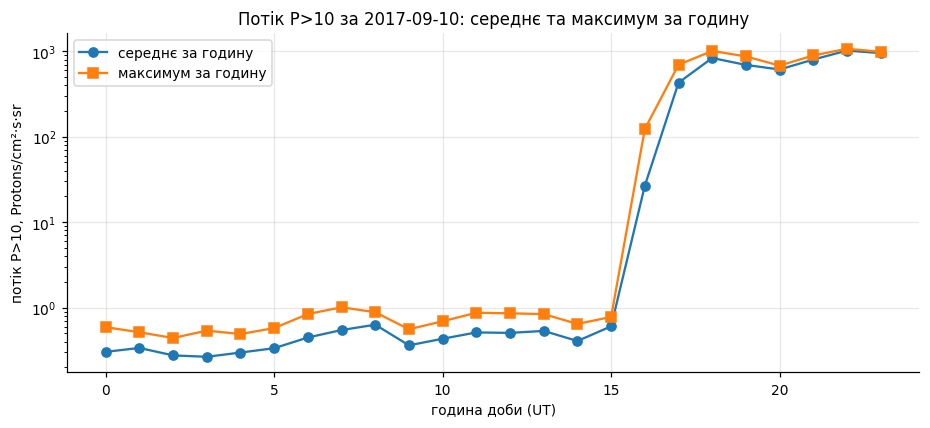

    P>10_mean  P>10_max  відношення
ts                                 
0        0.30      0.59        1.95
1        0.34      0.52        1.53
2        0.28      0.44        1.60
3        0.27      0.54        2.02
4        0.30      0.49        1.65
5        0.34      0.58        1.72
6        0.45      0.84        1.88
7        0.55      1.01        1.85
8        0.63      0.88        1.40
9        0.36      0.56        1.54
10       0.43      0.69        1.60
11       0.51      0.87        1.70
12       0.51      0.86        1.69
13       0.53      0.84        1.57
14       0.41      0.64        1.59
15       0.60      0.78        1.29
16      26.71    123.00        4.61
17     429.33    695.00        1.62
18     834.75   1010.00        1.21
19     692.83    871.00        1.26
20     612.42    680.00        1.11
21     800.92    894.00        1.12
22    1019.92   1070.00        1.05
23     952.25    988.00        1.04


In [171]:
ДОБА = '2017-09-10'
доба = A_год[A_год['ts'].dt.strftime('%Y-%m-%d') == ДОБА]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(доба['ts'].dt.hour, доба['P>10_mean'], marker='o', label='середнє за годину')
ax.plot(доба['ts'].dt.hour, доба['P>10_max'],  marker='s', label='максимум за годину')
ax.set_yscale('log')
ax.set_xlabel('година доби (UT)')
ax.set_ylabel('потік P>10, Protons/cm²·s·sr')
ax.set_title('Потік P>10 за %s: середнє та максимум за годину' % ДОБА)
ax.legend(); ax.grid(alpha=.3)
plt.show()

порівняння = доба[['ts', 'P>10_mean', 'P>10_max']].copy()
порівняння['відношення'] = порівняння['P>10_max'] / порівняння['P>10_mean']
print(порівняння.set_index(порівняння['ts'].dt.hour).drop(columns='ts').round(2).to_string())

**Відповідь 4.2:** Обидві криві показують той самий потік, але відповідають на різні питання. Середнє за годину каже, скільки частинок було типово протягом години — воно враховує всі 12 пʼятихвилинних вимірювань. Максимум каже, наскільки сильним був найгірший момент усередині години, і повністю ігнорує решту 11 значень.

### Завдання 4.3

Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки, у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`). Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [172]:
C_год = C[['ts', 'швидкість', 'густина']]

# B: доба - година, одне значення розтягується на 24 години
B_год = B[['ts', 'F10.7']].set_index('ts').resample('1h').ffill().reset_index()

for how in ['inner', 'outer']:
    tmp = A_год.merge(C_год, on='ts', how=how).merge(B_год, on='ts', how=how)
    print('how=%-6s -> %d рядків, рядків з пропусками: %d'
          % (how, len(tmp), tmp.isna().any(axis=1).sum()))

M = A_год.merge(C_год, on='ts', how='outer').merge(B_год, on='ts', how='outer')

print('\nM:', M.shape)
print('\nПропуски по стовпцях:')
print(M.isna().sum()[M.isna().sum() > 0].to_string())
print('\nРядки з пропусками:')
print(M[M.isna().any(axis=1)][['ts', 'P>10_mean', 'швидкість', 'густина', 'F10.7']].to_string())

how=inner  -> 577 рядків, рядків з пропусками: 8
how=outer  -> 601 рядків, рядків з пропусками: 32

M: (601, 20)

Пропуски по стовпцях:
P>1_mean       1
P>1_max        1
P>5_mean       1
P>5_max        1
P>10_mean      1
P>10_max       1
P>30_mean      1
P>30_max       1
P>50_mean      1
P>50_max       1
P>100_mean     1
P>100_max      1
E>0.8_mean     1
E>0.8_max      1
E>2.0_mean     1
E>2.0_max      1
швидкість      8
густина        8
F10.7         24

Рядки з пропусками:
                     ts  P>10_mean  швидкість  густина  F10.7
175 2017-09-04 07:00:00   0.171500        NaN      NaN  140.0
176 2017-09-04 08:00:00   0.195833        NaN      NaN  140.0
177 2017-09-04 09:00:00   0.220333        NaN      NaN  140.0
178 2017-09-04 10:00:00   0.181833        NaN      NaN  140.0
179 2017-09-04 11:00:00   0.186917        NaN      NaN  140.0
180 2017-09-04 12:00:00   0.153500        NaN      NaN  140.0
181 2017-09-04 13:00:00   0.192833        NaN      NaN  140.0
182 2017-09-04 14:00:00 

**Відповідь 4.3:** inner дає 577 рядків, outer — 601. Різниця в 24 рядки виникає тому, що таблиці покривають не однаковий період: A закінчується 21 вересня о 23:55, C тягнеться до 22 вересня 00:00, а B обривається на 21 вересня 00:00.

### Завдання 4.4 — поділ на групи

Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням **максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [173]:
M['група'] = pd.cut(M['P>10_max'],
                    bins=[-float('inf'), 10, 1000, float('inf')],
                    labels=['тиха', 'активна', 'дуже активна'],
                    right=False)

print(M['група'].value_counts().reindex(['тиха', 'активна', 'дуже активна']).to_string())
print('\nбез групи (NaN):', M['група'].isna().sum())

група
тиха            411
активна         171
дуже активна     18

без групи (NaN): 1


**Самоперевірка етапу 4.**

In [174]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**. Не «на графіку зображено потік протонів», а твердження на кшталт «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно — так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?

Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не залишайте так. Спробуйте побудувати гістограму від логарифма значень (`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

середнє : 76.45
медіана : 0.3433


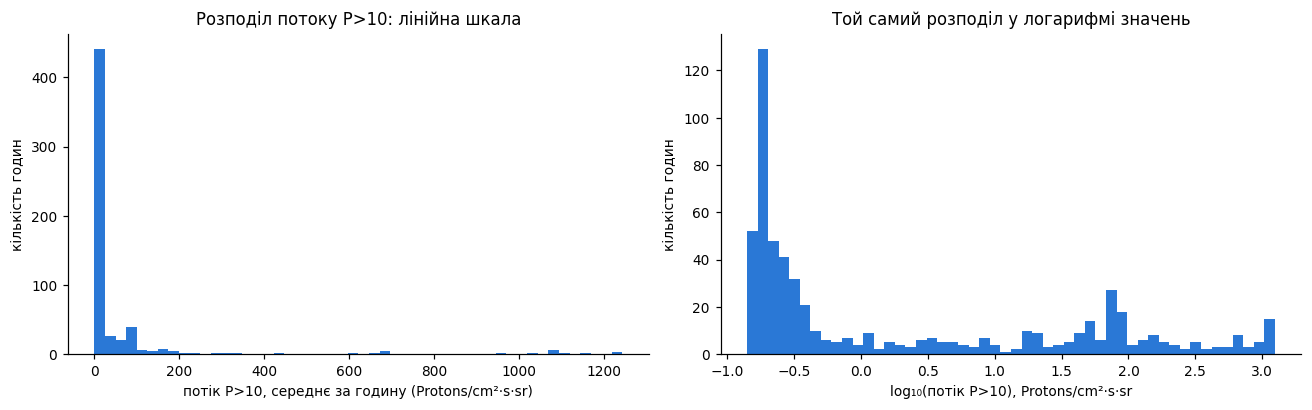

In [175]:
x = M['P>10_mean'].dropna()
print('середнє : %.2f' % x.mean())
print('медіана : %.4f' % x.median())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

ax[0].hist(x, bins=50, color='#2a78d6')
ax[0].set_xlabel('потік P>10, середнє за годину (Protons/cm²·s·sr)')
ax[0].set_ylabel('кількість годин')
ax[0].set_title('Розподіл потоку P>10: лінійна шкала')

ax[1].hist(np.log10(x[x > 0]), bins=50, color='#2a78d6')
ax[1].set_xlabel('log₁₀(потік P>10), Protons/cm²·s·sr')
ax[1].set_ylabel('кількість годин')
ax[1].set_title('Той самий розподіл у логарифмі значень')

fig.tight_layout(); plt.show()

**Висновок:** Середнє 76.45 і медіана 0.343 відрізняються у 223 рази, бо розподіл сильно асиметричний з довгим правим хвостом. Медіана - це значення посередині впорядкованого ряду, і на неї впливає лише кількість великих значень, а не їхня величина. Середнє ж підсумовує всі значення, тому кожна година спалаху з потоком 1000 важить у ньому стільки ж, скільки три тисячі спокійних годин із потоком 0.3

### Графік 2. Чи відрізняється швидкість вітру між групами годин?

Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної групи з завдання 4.4.

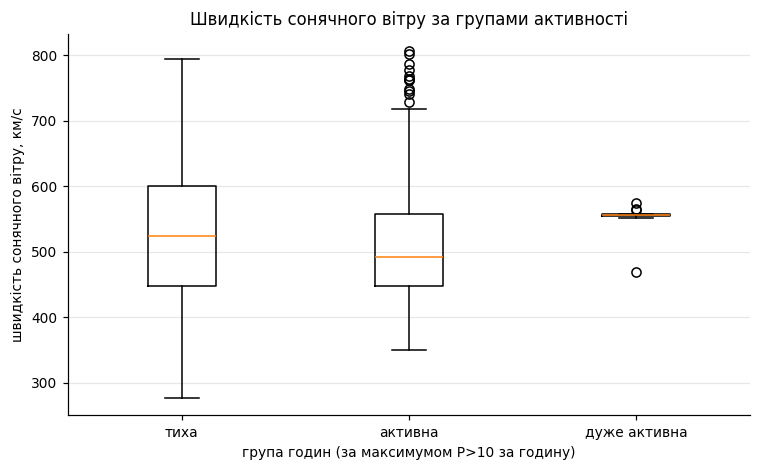

              count  median   mean    min    max
група                                           
тиха            403   524.0  511.3  277.0  795.0
активна         171   492.0  515.1  350.0  806.0
дуже активна     18   556.0  552.9  469.0  575.0


In [176]:
групи = ['тиха', 'активна', 'дуже активна']
дані = [M.loc[M['група'] == g, 'швидкість'].dropna() for g in групи]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(дані, tick_labels=групи)
ax.set_xlabel('група годин (за максимумом P>10 за годину)')
ax.set_ylabel('швидкість сонячного вітру, км/с')
ax.set_title('Швидкість сонячного вітру за групами активності')
ax.grid(alpha=.3, axis='y')
plt.show()

print(M.groupby('група', observed=True)['швидкість']
      .agg(['count', 'median', 'mean', 'min', 'max']).round(1).to_string())

**Висновок:** Медіанна швидкість вітру в тихих і активних годинах практично однакова (524 проти 492 км/с) при розкиді всередині кожної групи понад 150 км/с, тож коробки перекриваються і зв'язку між потоком протонів P>10 та швидкістю сонячного вітру в цьому вікні не видно. Вузька третя коробка (IQR = 2 км/с) - не фізичний ефект, а наслідок того, що група «дуже активна» складається з 18 годин, 16 з яких припадають на одну добу 11 вересня, за яку вітер просто не встиг змінитися.

### Графік 3. Чи пов'язані змінні вашої пари?

Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт кореляції між ними.

Пірсон  : -0.082
Спірмен : 0.001
точок   : 577


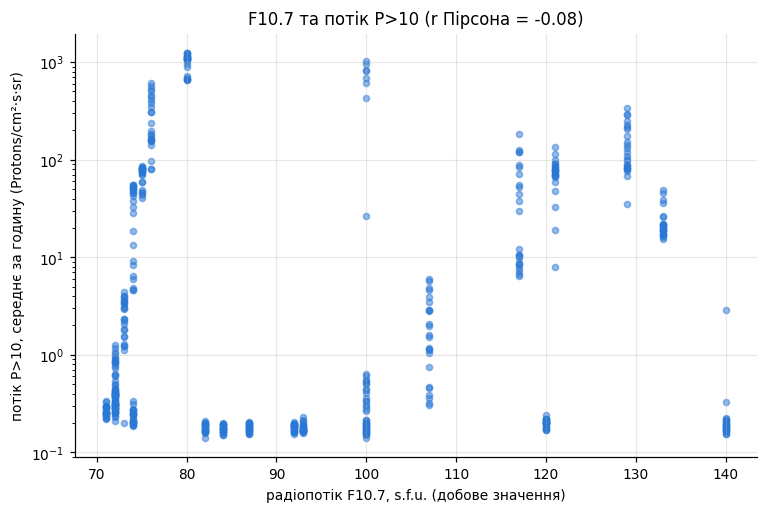

In [177]:
пара = M[['F10.7', 'P>10_mean']].dropna()

r_pearson  = пара.corr().iloc[0, 1]
r_spearman = пара.corr(method='spearman').iloc[0, 1]
print('Пірсон  : %.3f' % r_pearson)
print('Спірмен : %.3f' % r_spearman)
print('точок   :', len(пара))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(пара['F10.7'], пара['P>10_mean'], s=16, alpha=.5, color='#2a78d6')
ax.set_yscale('log')
ax.set_xlabel('радіопотік F10.7, s.f.u. (добове значення)')
ax.set_ylabel('потік P>10, середнє за годину (Protons/cm²·s·sr)')
ax.set_title('F10.7 та потік P>10 (r Пірсона = %.2f)' % r_pearson)
ax.grid(alpha=.3)
plt.show()

**Висновок:** зв'язку немає ( кореляція майже 0 ) F10.7 і P>10 міряють різні явища. F10.7 - це фоновий радіовипромінювальний рівень усього Сонця, він змінюється повільно і показує, скільки взагалі на диску активних областей. P>10 - це протони від окремої події: спалаху й викиду корональної маси.

### Графік 4. Скільки годин у кожній групі?

Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик кількістю годин і відсотком від загальної кількості.

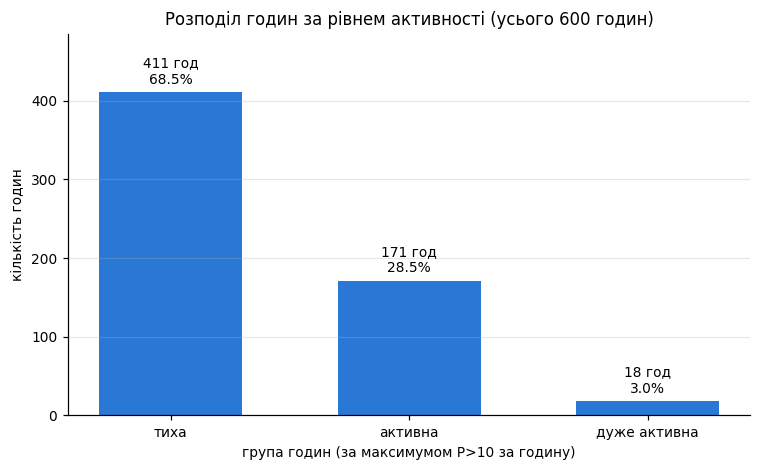

              годин  частка, %
група                         
тиха            411       68.5
активна         171       28.5
дуже активна     18        3.0

без групи (NaN): 1


In [178]:
лічильник = M['група'].value_counts().reindex(['тиха', 'активна', 'дуже активна'])
усього = лічильник.sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
стовпці = ax.bar(лічильник.index, лічильник.values, color='#2a78d6', width=.6)

for стовпчик, n in zip(стовпці, лічильник.values):
    ax.text(стовпчик.get_x() + стовпчик.get_width() / 2,
            n + усього * .012,
            '%d год\n%.1f%%' % (n, 100 * n / усього),
            ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, лічильник.max() * 1.18)
ax.set_xlabel('група годин (за максимумом P>10 за годину)')
ax.set_ylabel('кількість годин')
ax.set_title('Розподіл годин за рівнем активності (усього %d годин)' % усього)
ax.grid(alpha=.3, axis='y')
plt.show()

print(pd.DataFrame({'годин': лічильник,
                    'частка, %': (100 * лічильник / усього).round(1)}).to_string())
print('\nбез групи (NaN):', M['група'].isna().sum())

**Висновок:** Дві третини всіх годин вікна (411, 68.5%) - спокійний фон, і лише 18 годин (3.0%) дотягують до порогу сильної бурі

### Графік 5. Як усе це виглядало в часі?

Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

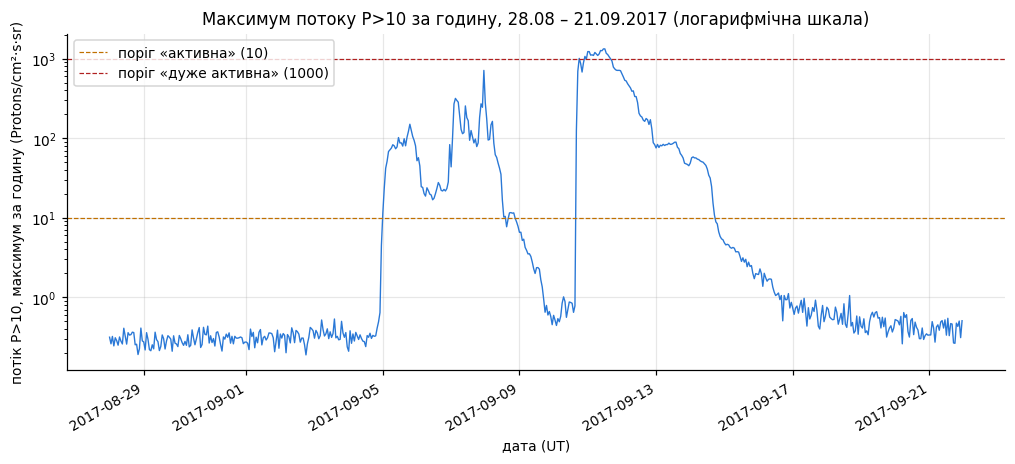

мінімум 0.188, максимум 1330, відношення 7074 разів
пік: 2017-09-11 11:00:00
годин вище порога 10: 189 | з 2017-09-05 00:00:00 до 2017-09-14 17:00:00


In [179]:
крива = M.dropna(subset=['P>10_max'])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(крива['ts'], крива['P>10_max'], color='#2a78d6', linewidth=.9)
ax.set_yscale('log')
ax.axhline(10,   color='#c07000', linestyle='--', linewidth=.8, label='поріг «активна» (10)')
ax.axhline(1000, color='#b02020', linestyle='--', linewidth=.8, label='поріг «дуже активна» (1000)')
ax.set_xlabel('дата (UT)')
ax.set_ylabel('потік P>10, максимум за годину (Protons/cm²·s·sr)')
ax.set_title('Максимум потоку P>10 за годину, 28.08 – 21.09.2017 (логарифмічна шкала)')
ax.legend(loc='upper left'); ax.grid(alpha=.3)
fig.autofmt_xdate()
plt.show()

x = крива['P>10_max']
print('мінімум %.3f, максимум %.0f, відношення %.0f разів' % (x.min(), x.max(), x.max() / x.min()))
print('пік:', крива.loc[x.idxmax(), 'ts'])
print('годин вище порога 10:', (x >= 10).sum(),
      '| з', крива.loc[x >= 10, 'ts'].min(), 'до', крива.loc[x >= 10, 'ts'].max())

**Висновок:** Майже весь місяць потік P>10 тримається на низькому фоні близько 0.3, і лише з 5 по 14 вересня різко підскакує - аж до 1330 вранці 11 вересня. Тобто вся активність - це одна подія, а не поступове наростання.

# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

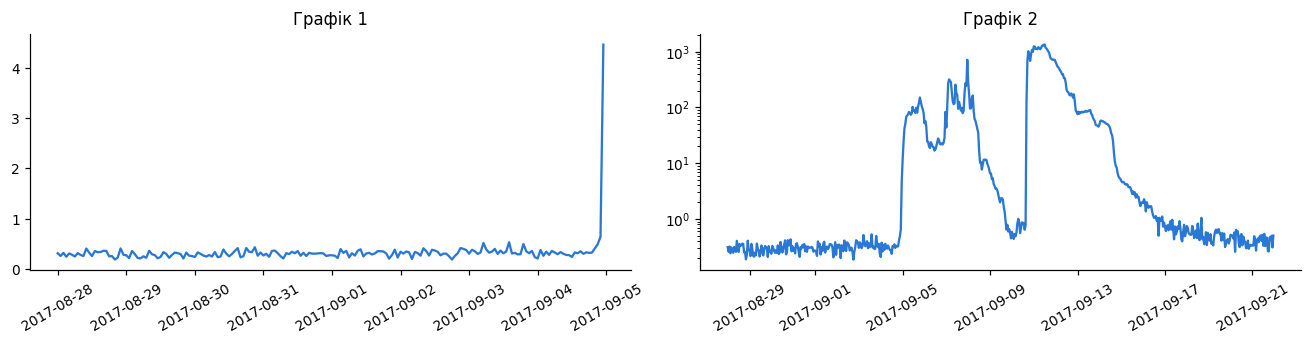

In [180]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1

Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності — вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те, як їх побудували.*

**Відповідь 6.1:**

1. Що вересень 2017 був спокійним місяцем: потік тримається на рівні близько 0.4 і лише в самому кінці графіка ледь піднімається, тож жодної бурі ця людина не побачить
2. Що у вересні 2017 була потужна радіаційна буря: з 5 по 14 вересня потік злітає на три-чотири порядки й досягає 1330 — і водночас видно, що решту місяця було тихо.
3. Дві відмінності між ними: Перша відмінність - період: лівий графік показує лише зріз M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')], тобто вісім діб до початку події, а правий - усі 600 годин вікна. Друга - шкала осі Y: у правому графіку стоїть ax.set_yscale('log'), а в лівому шкала залишилась лінійною, тому там і не видно розмаху в чотири порядки.

### Завдання 6.2

Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

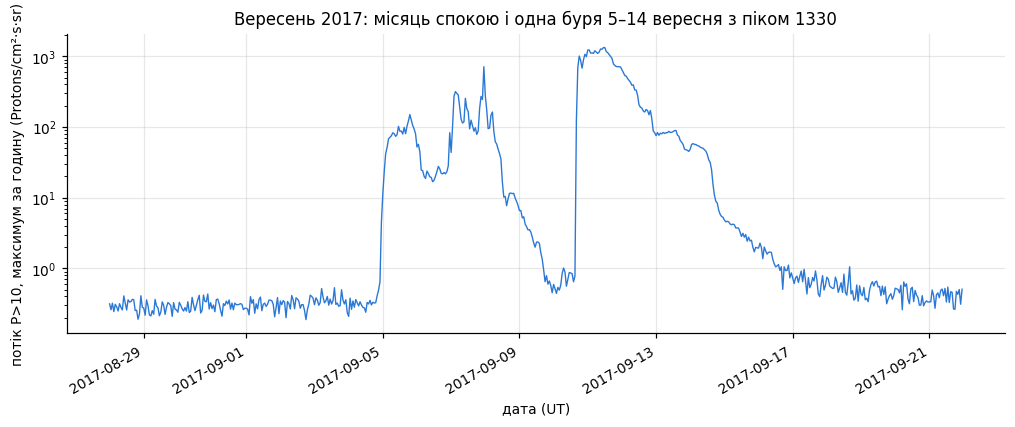

In [181]:
крива = M.dropna(subset=['P>10_max'])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(крива['ts'], крива['P>10_max'], color='#2a78d6', linewidth=.9)
ax.set_yscale('log')
ax.set_xlabel('дата (UT)')
ax.set_ylabel('потік P>10, максимум за годину (Protons/cm²·s·sr)')
ax.set_title('Вересень 2017: місяць спокою і одна буря 5–14 вересня з піком 1330')
ax.grid(alpha=.3)
fig.autofmt_xdate()
plt.show()

**Відповідь 6.2:** Я взяв увесь період спостережень і логарифмічну шкалу по Y

# Етап 7. Три спостереження та ваше питання

### Завдання 7.1

Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Середнє потоку P>10 (76.45) у 223 рази більше за медіану (0.343) - бо кілька годин бурі перетягують середнє на себе. Видно у графіку 1.

**Спостереження 2:** Усі 18 «дуже активних» годин припадають лише на дві доби - 10 і 11 вересня. Видно у графіку 4 і в перевірці по добах.

**Спостереження 3:** Пік радіопотоку F10.7 (4 вересня) і пік потоку протонів (11 вересня) розділені тижнем, тому кореляція між ними нульова (−0.08). Видно у графіку 3.

### Завдання 7.2 — ваше індивідуальне питання

Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [182]:
# ВАШ КОД

**Відповідь 7.2:**

# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом — так само, як у науковій статті вказують використане програмне забезпечення. **Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1

Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться за висновки, а не за наявність абзацу.

In [183]:
ІНСТРУМЕНТИ_ШІ = 'Claude, chatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'код, перевірено',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'При розподілі таблиць були спочатку не правильно пораховані "не заповнені" колонки тому попросив ще раз перевірити. + Коли рахував колєрацію питав в клода для чого дивитись кореляцію по 2 методам а чому не достатньо одного'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [184]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Кривичко Назар
інструменти:                                   Claude, chatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                код, перевірено
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
При розподілі таблиць були спочатку не правильно пораховані "не заповнені" колонки тому попросив ще раз перевірити. + Коли рахував колєрацію питав в клода для чого дивитись кореляцію по 2 методам а чому не достатньо одного
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її й не втрачайте до кінця семестру.

In [185]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [186]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
